Stage 2b — Forecasting Brent returns

Target: next-step log return, log(P_t+1 / P_t), converted back to a price for
reporting with P_hat = P_t * exp(y_hat).

In [2]:
import json
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.width", 150)
pd.set_option("display.max_columns", 60)

REPORTS, METRICS, PROCESSED = "results/reports", "results/metrics", "datasets/processed"
for d in (REPORTS, METRICS):
    os.makedirs(d, exist_ok=True)

from src.data.loaders import attach_weekly
from src.features.build import build_feature_frame

TEST_START = pd.Timestamp("2026-02-24")
CONFLICT_ONSET = pd.Timestamp("2026-03-16")
LAGS = [1, 2, 3, 5, 10]

How to read this notebook

The order is deliberate and is the order the checks have to happen in: build
the split, score the benchmark, then score everything else against it. A model
result that appears before a benchmark result has nothing to be measured
against.

Three conventions carry through:

- **The benchmark is the bar.** Brent returns are close to a random walk, so
`naive_random_walk` predicting zero is genuinely hard to beat. Beating it is
the claim; posting a low RMSE is not.
- **Two unit systems.** Error is reported in log-return units and in USD/bbl
from the same predictions, because model rankings can differ between them.
- **The test decides.** A smaller RMSE is not a result until a
Diebold-Mariano test says the difference is larger than the noise.

If nothing beats the benchmark, that is written in the headline rather than
worked around by hunting for a specification that reverses it.

In [4]:
HORIZONS = (1,)
MODEL_KEYS = ['elasticnet', 'random_forest', 'gradient_boosting']
N_ITER = 6
REFIT_ORIGINS = 5
USE_REGIME = False
print("horizons", HORIZONS, " roster", MODEL_KEYS)

horizons (1,)  roster ['elasticnet', 'random_forest', 'gradient_boosting']


Load the model frame

Built by `04_feature_build.py`. Rebuilt here if that has not been run, so this
notebook is runnable on its own.

In [6]:
frame_path = f"{PROCESSED}/model_frame.csv"
if os.path.exists(frame_path):
    frame = pd.read_csv(frame_path, parse_dates=["date"]).set_index("date")
    ycols = [c for c in frame.columns if c.startswith("h") and c[1:].isdigit()]
    X, y = frame.drop(columns=ycols), frame[ycols]
    print("loaded", frame_path, frame.shape)
else:
    daily = pd.read_csv(f"{PROCESSED}/master_daily.csv", parse_dates=["date"]).set_index("date").sort_index()
    weekly = pd.read_csv(f"{PROCESSED}/master_weekly.csv", parse_dates=["week_start"]).set_index("week_start").sort_index()
    merged = attach_weekly(daily, weekly).drop(columns=["published_on"], errors="ignore")
    merged = merged.select_dtypes("number").ffill().dropna()
    X, y = build_feature_frame(merged, price_col="brent_close", lags=LAGS, horizons=HORIZONS)
    print("rebuilt feature frame", X.shape)

daily_px = pd.read_csv(f"{PROCESSED}/master_daily.csv", parse_dates=["date"]).set_index("date").sort_index()
price = daily_px["brent_close"].reindex(X.index)
regime = pd.Series(X.index >= CONFLICT_ONSET, index=X.index)
REGIME_MASK = regime if USE_REGIME else None

print("lags used:", LAGS)
print("X", X.shape, " targets", list(y.columns))
print("conflict share of the sample:", round(float(regime.mean()), 3))

loaded datasets/processed/model_frame.csv (264, 71)
lags used: [1, 2, 3, 5, 10]
X (264, 70)  targets ['h1']
conflict share of the sample: 0.22


Walk-forward split

Chronological expanding origins with a purge gap between the end of training
and the forecast origin. No shuffle, no KFold, no train_test_split. Every
model, benchmarks included, is scored on the same origins.

In [8]:
from src.models.walkforward import SplitSpec, build_results_table, run_walk_forward

spec_preview = SplitSpec(test_start=TEST_START, purge=10, min_train=120, horizon=1)
origins = spec_preview.origins(X.index)
train_end = spec_preview.train_slice(X.index, origins[0])[-1]
print(f"{len(origins)} forecast origins, {origins[0].date()} .. {origins[-1].date()}")
print("training begins", X.index[0].date(), " first training block ends", train_end.date())
print("purge gap:", spec_preview.purge, "trading days")
print("origins in the conflict regime:", int(regime.reindex(origins).sum()),
      " outside:", int((~regime.reindex(origins)).sum()))

72 forecast origins, 2026-02-24 .. 2026-06-23
training begins 2025-03-05  first training block ends 2026-02-09
purge gap: 10 trading days
origins in the conflict regime: 58  outside: 14


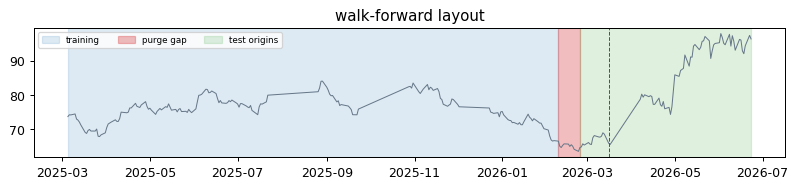

In [9]:
fig, ax = plt.subplots(figsize=(9, 2.2))
ax.plot(price.index, price, lw=.8, color="#678")
ax.axvspan(X.index[0], train_end, alpha=.15, color="tab:blue", label="training")
ax.axvspan(train_end, origins[0], alpha=.3, color="tab:red", label="purge gap")
ax.axvspan(origins[0], origins[-1], alpha=.15, color="tab:green", label="test origins")
ax.axvline(CONFLICT_ONSET, color="crimson", ls="--", lw=.8)
ax.legend(fontsize=7, ncol=3)
ax.set_title("walk-forward layout")
plt.tight_layout()

**What the purge gap is for.** Training stops several days before the forecast
origin rather than immediately before it. Features here use rolling windows of
up to 21 days, so a training row adjacent to the origin overlaps the window the
forecast is made from, and the model gets a partial view of its own target
period. The gap removes that overlap.

The origins are fixed once, here, and every model is scored on exactly this
set. A benchmark evaluated on a different set of origins is not a benchmark, it
is a second unrelated number.

Fit

Benchmarks first: the naive random walk and the drift model are fitted and
scored before anything else in the roster. Each roster model is tuned by
randomised search on blocked time-series cross-validation with a purge gap, and
the CV score is reported next to the test score.

In [12]:
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from src.models.roster import ROSTER, simplest_setting

# Trim the tree search spaces: the walk-forward loop refits at every origin, so a
# 800-tree grid multiplies out into thousands of fits for no gain at this sample
# size. The search itself is unchanged.
if "random_forest" in ROSTER:
    ROSTER["random_forest"]["param_dist"]["est__n_estimators"] = [60, 120]
if "gradient_boosting" in ROSTER:
    ROSTER["gradient_boosting"]["param_dist"]["est__n_estimators"] = [60, 120]

for k in MODEL_KEYS:
    print(k, "->", ROSTER[k]["param_dist"])
print()
print("cv:", TimeSeriesSplit(n_splits=5, gap=10), " n_iter:", N_ITER)
print()
print(f"estimators are refitted every {REFIT_ORIGINS} origins on the expanding window.")
print("Between refits the model is older, never better informed: no model ever")
print("sees data past its own forecast origin, and the scored origins are unchanged.")

elasticnet -> {'est__alpha': [0.0001, 0.001, 0.01, 0.1, 1.0], 'est__l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9, 1.0]}
random_forest -> {'est__n_estimators': [60, 120], 'est__max_depth': [2, 3, 5, None], 'est__min_samples_leaf': [1, 5, 10, 20], 'est__max_features': ['sqrt', 0.3, 0.6]}
gradient_boosting -> {'est__n_estimators': [60, 120], 'est__learning_rate': [0.01, 0.03, 0.1], 'est__max_depth': [1, 2, 3], 'est__subsample': [0.6, 0.8, 1.0]}

cv: TimeSeriesSplit(gap=10, max_train_size=None, n_splits=5, test_size=None)  n_iter: 6

estimators are refitted every 5 origins on the expanding window.
Between refits the model is older, never better informed: no model ever
sees data past its own forecast origin, and the scored origins are unchanged.


In [13]:
records = []
cv_notes = []
for h in HORIZONS:
    spec = SplitSpec(test_start=TEST_START, purge=10, min_train=120, horizon=h)
    res = run_walk_forward(X, y[f"h{h}"], spec, model_keys=MODEL_KEYS,
                           n_iter=N_ITER, refit_every=10_000,
                           model_refit_every=REFIT_ORIGINS)
    records += build_results_table(res, price, regime_mask=REGIME_MASK)
    for r in res:
        if r.cv_score is not None:
            cv_notes.append({"model": r.model, "horizon": h, "cv_rmse": round(r.cv_score, 6),
                             "picked_simplest": r.picked_simplest, "params": r.best_params})
            print(f"h={h} {r.model:<20} cv_rmse={r.cv_score:.6f} "
                  f"simplest={r.picked_simplest} {r.best_params}")
    globals()["last_res"] = res

print()
print(len(records), "result records")
simplest_count = sum(1 for c in cv_notes if c["picked_simplest"])
print(f"{simplest_count} of {len(cv_notes)} tuned fits chose the most-regularised setting on offer.")
if simplest_count:
    print("That is cross-validation saying the added complexity is not paying for")
    print("itself. It is a finding, not a footnote.")

h=1 elasticnet           cv_rmse=0.011940 simplest=False {'est__l1_ratio': 0.9, 'est__alpha': 1.0}
h=1 random_forest        cv_rmse=0.011790 simplest=False {'est__n_estimators': 120, 'est__min_samples_leaf': 20, 'est__max_features': 'sqrt', 'est__max_depth': 5}
h=1 gradient_boosting    cv_rmse=0.012123 simplest=False {'est__subsample': 1.0, 'est__n_estimators': 120, 'est__max_depth': 2, 'est__learning_rate': 0.01}

5 result records
0 of 3 tuned fits chose the most-regularised setting on offer.


**Reading the CV output.** The cross-validation score is reported next to the
test score so the two can disagree in the open. If the search selected the
most-regularised setting available, that is cross-validation saying the extra
flexibility hurt out of sample — a result about the problem, not a tuning
detail to bury.

The scaler sits inside the pipeline, so it is refitted on each fold rather than
once on the whole frame. Fitting it once is leakage even when the split itself
is correct, and it is the most common way a clean-looking harness leaks.

Model comparison

The benchmark sits on the first row. RMSE is reported in log-return units and
in USD/bbl, derived from the same predictions, because rankings can differ
between the two.

In [16]:
table = pd.DataFrame([r for r in records if r.get("regime") == "all"])
cols = [c for c in ["model", "horizon", "n", "rmse_logret", "rmse_usd", "mae_logret",
                    "r2", "diracc", "cv_rmse", "dm_stat", "dm_pvalue", "verdict"]
        if c in table.columns]
table = table[cols]
print(table.to_string(index=False))

            model  horizon  n  rmse_logret  rmse_usd  mae_logret      r2  diracc  cv_rmse  dm_stat  dm_pvalue                                  verdict
naive_random_walk        1 72     0.022213    1.9276    0.017067 -0.0204  0.0000      NaN      NaN        NaN                                benchmark
            drift        1 72     0.022352    1.9386    0.017178 -0.0333  0.4306      NaN   1.6210     0.1095 no significant difference from benchmark
       elasticnet        1 72     0.022342    1.9377    0.017170 -0.0324  0.4583 0.011940   1.5047     0.1368 no significant difference from benchmark
    random_forest        1 72     0.022308    1.9354    0.016939 -0.0292  0.5000 0.011790   0.2925     0.7708 no significant difference from benchmark
gradient_boosting        1 72     0.023096    2.0140    0.017527 -0.1032  0.5417 0.012123   1.0525     0.2961 no significant difference from benchmark


In [17]:
for h in sorted(table["horizon"].unique()):
    sub = table[table["horizon"] == h]
    print()
    print(f"--- horizon h={h} ---")
    print(sub[[c for c in ["model", "n", "rmse_logret", "rmse_usd", "r2", "diracc"] if c in sub.columns]]
          .to_string(index=False))
    bench = sub[sub["model"] == "naive_random_walk"]
    if len(bench):
        b = float(bench["rmse_logret"].iloc[0])
        for _, r in sub.iterrows():
            delta = 100 * (float(r["rmse_logret"]) - b) / b
            print(f"  {r['model']:<20} {delta:+.2f}% RMSE vs the benchmark")


--- horizon h=1 ---
            model  n  rmse_logret  rmse_usd      r2  diracc
naive_random_walk 72     0.022213    1.9276 -0.0204  0.0000
            drift 72     0.022352    1.9386 -0.0333  0.4306
       elasticnet 72     0.022342    1.9377 -0.0324  0.4583
    random_forest 72     0.022308    1.9354 -0.0292  0.5000
gradient_boosting 72     0.023096    2.0140 -0.1032  0.5417
  naive_random_walk    +0.00% RMSE vs the benchmark
  drift                +0.63% RMSE vs the benchmark
  elasticnet           +0.58% RMSE vs the benchmark
  random_forest        +0.43% RMSE vs the benchmark
  gradient_boosting    +3.98% RMSE vs the benchmark


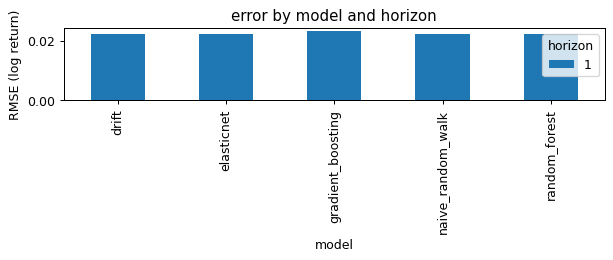

In [18]:
fig, ax = plt.subplots(figsize=(7, 3))
piv = table.pivot_table(index="model", columns="horizon", values="rmse_logret")
piv.plot(kind="bar", ax=ax)
ax.set_ylabel("RMSE (log return)")
ax.set_title("error by model and horizon")
plt.tight_layout()

**What the percentages mean.** Each model's RMSE is shown as a percentage
difference from the naive benchmark, so a positive number is worse. Small
positive numbers across the board are the expected outcome for daily oil
returns and should not be read as a near-miss.

R-squared below zero is not a bug: it means the model predicts the test block
worse than that block's own mean would.

Diebold-Mariano against the naive benchmark

An RMSE difference is not a result. The sign convention is stated so the
verdict cannot be read backwards.

In [21]:
from src.stats.tests import SIGN_CONVENTION

print(SIGN_CONVENTION)
print()
dm = table[table["model"] != "naive_random_walk"]
print(dm[[c for c in ["model", "horizon", "n", "dm_stat", "dm_pvalue", "verdict"] if c in dm.columns]]
      .to_string(index=False))

beat = [r for r in records if r.get("regime") == "all" and r.get("dm_pvalue") is not None
        and r["dm_pvalue"] < 0.05 and (r.get("dm_stat") or 0) < 0]
HEADLINE = ("Nothing beat the naive random walk at the 5% level."
            if not beat else f"{len(beat)} model-horizon combination(s) beat the benchmark.")
print()
print("HEADLINE:", HEADLINE)

underpowered = [r for r in records if r.get("regime") == "all"
                and isinstance(r.get("n_origins"), int) and r["n_origins"] < 20]
if underpowered:
    print()
    print(f"{len(underpowered)} comparison(s) run on fewer than 20 origins. A DM test on")
    print("that few cannot separate a real edge from luck in either direction.")

DM > 0 means the model has HIGHER loss than the benchmark, i.e. the model is WORSE. DM < 0 means the model is better. The p-value is two-sided.

            model  horizon  n  dm_stat  dm_pvalue                                  verdict
            drift        1 72   1.6210     0.1095 no significant difference from benchmark
       elasticnet        1 72   1.5047     0.1368 no significant difference from benchmark
    random_forest        1 72   0.2925     0.7708 no significant difference from benchmark
gradient_boosting        1 72   1.0525     0.2961 no significant difference from benchmark

HEADLINE: Nothing beat the naive random walk at the 5% level.


**Reading the DM test.** The statistic compares the two models' loss
differentials rather than their raw errors, which is what makes it a test
rather than a comparison. The sign convention is printed above the table
because it is easy to invert, and inverting it reverses the conclusion.

A p-value above 0.05 means the difference is inside what this many origins
could produce by chance. With fewer than about twenty origins the test cannot
separate a real edge from luck in either direction, so a null there is weak
evidence rather than evidence of no effect.

Residual diagnostics

A model can post a respectable RMSE and still be misspecified. These check that
the errors look like noise rather than like structure the model missed.

model: elasticnet  residuals: 72
mean 0.003823  std 0.022167
skew -0.0039  kurtosis 0.2432

Ljung-Box on residuals (low p = leftover autocorrelation):
    lb_stat  lb_pvalue
5    1.7611     0.8811
10   3.6959     0.9600


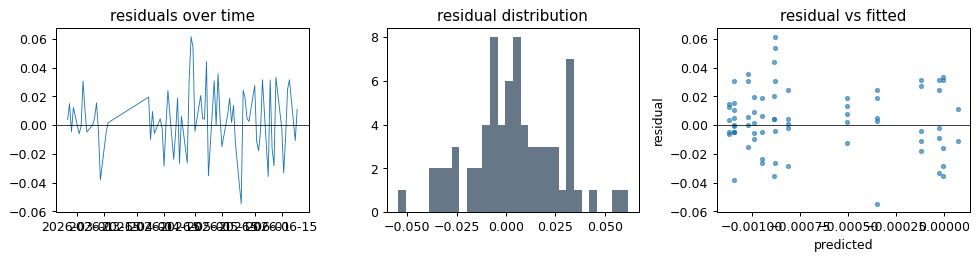

In [24]:
from statsmodels.stats.diagnostic import acorr_ljungbox

res_obj = globals().get("last_res")
if res_obj:
    target_model = [r for r in res_obj if r.model not in ("naive_random_walk", "drift")]
    if target_model:
        r0 = target_model[0]
        resid = (r0.actuals - r0.predictions).dropna()
        print("model:", r0.model, " residuals:", len(resid))
        print("mean", round(float(resid.mean()), 6), " std", round(float(resid.std()), 6))
        print("skew", round(float(resid.skew()), 4), " kurtosis", round(float(resid.kurtosis()), 4))
        lb = acorr_ljungbox(resid, lags=[5, 10], return_df=True)
        print()
        print("Ljung-Box on residuals (low p = leftover autocorrelation):")
        print(lb.round(4).to_string())

        fig, axes = plt.subplots(1, 3, figsize=(11, 3))
        axes[0].plot(resid.index, resid, lw=.7)
        axes[0].axhline(0, c="k", lw=.6)
        axes[0].set_title("residuals over time")
        axes[1].hist(resid, bins=30, color="#678")
        axes[1].set_title("residual distribution")
        axes[2].scatter(r0.predictions.reindex(resid.index), resid, s=10, alpha=.6)
        axes[2].axhline(0, c="k", lw=.6)
        axes[2].set_xlabel("predicted"); axes[2].set_ylabel("residual")
        axes[2].set_title("residual vs fitted")
        plt.tight_layout()

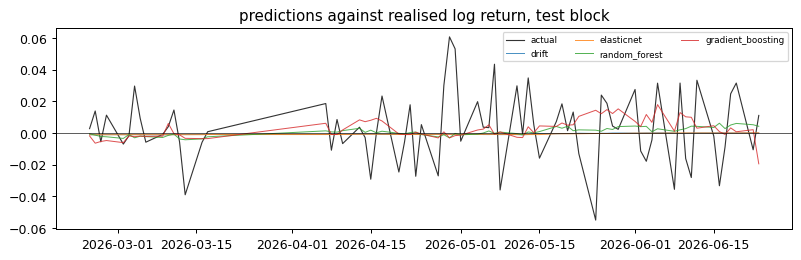

In [25]:
if res_obj:
    bench = [r for r in res_obj if r.model == "naive_random_walk"][0]
    fig, ax = plt.subplots(figsize=(9, 3))
    ax.plot(bench.actuals.index, bench.actuals, lw=.9, label="actual", color="#333")
    for r in res_obj:
        if r.model != "naive_random_walk":
            ax.plot(r.predictions.index, r.predictions, lw=.8, alpha=.8, label=r.model)
    ax.axhline(0, c="k", lw=.5)
    ax.legend(fontsize=7, ncol=3)
    ax.set_title("predictions against realised log return, test block")
    plt.tight_layout()

**What good residuals look like.** No visible trend against time, no fan shape
against the fitted values, and a high Ljung-Box p-value meaning no leftover
autocorrelation for the model to have exploited.

A fan shape would say the errors grow with the prediction, which for this data
usually means the model has picked up the volatility regime rather than
direction. Leftover autocorrelation would say there is structure the model
missed, which is more interesting than a slightly better RMSE.

Coefficients and feature importance

Reported and read, not merely plotted.

In [28]:
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from src.models.roster import ROSTER, feature_importance

train_idx = X.index[X.index < TEST_START]
imp_tables = {}
for key in MODEL_KEYS:
    cfg = ROSTER[key]
    srch = RandomizedSearchCV(cfg["estimator"], cfg["param_dist"], n_iter=N_ITER,
                              cv=TimeSeriesSplit(n_splits=5, gap=10),
                              scoring="neg_root_mean_squared_error", random_state=0, n_jobs=-1)
    srch.fit(X.loc[train_idx], y[f"h{HORIZONS[0]}"].loc[train_idx])
    imp = feature_importance(srch.best_estimator_, list(X.columns))
    imp_tables[key] = imp
    print(f"{key}: cv_rmse {(-srch.best_score_):.6f}  params {srch.best_params_}")
    print(f"  kind: {imp['kind']}  non-zero/non-trivial: {sum(1 for v in imp['values'].values() if v != 0)}")
    top = list(imp["values"].items())[:8]
    for name, val in top:
        print(f"    {name:<34} {val:>12.6f}")
    print()

elasticnet: cv_rmse 0.011867  params {'est__l1_ratio': 0.9, 'est__alpha': 1.0}
  kind: coefficient  non-zero/non-trivial: 0
    realised_return_lag1                   0.000000
    realised_return_lag2                   0.000000
    realised_return_lag3                   0.000000
    realised_return_lag5                   0.000000
    realised_return_lag10                  0.000000
    rv21_lag1                              0.000000
    rv21_lag2                              0.000000
    rv21_lag3                              0.000000

random_forest: cv_rmse 0.011698  params {'est__n_estimators': 120, 'est__min_samples_leaf': 20, 'est__max_features': 'sqrt', 'est__max_depth': 5}
  kind: impurity_importance  non-zero/non-trivial: 20
    tanker_rate_usd_lag10                  0.038568
    acled_fatalities_z21_lag2              0.038096
    realised_return_lag2                   0.037262
    tanker_rate_usd_lag3                   0.035319
    acled_events_z21_lag10                 0.034737

elasticnet: every coefficient was driven to zero.


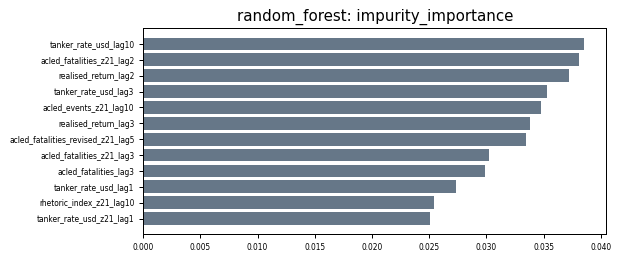

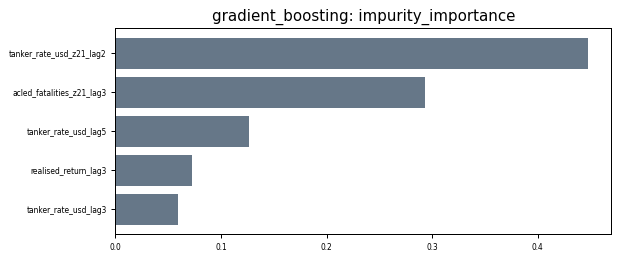

In [29]:
for key, imp in imp_tables.items():
    vals = {k: v for k, v in imp["values"].items() if v != 0}
    if not vals:
        print(f"{key}: every coefficient was driven to zero.")
        continue
    fig, ax = plt.subplots(figsize=(7, 3))
    names = list(vals)[:12][::-1]
    ax.barh(names, [vals[n] for n in names], color="#678")
    ax.set_title(f"{key}: {imp['kind']}")
    ax.tick_params(labelsize=6)
    plt.tight_layout()

In [30]:
zeroed = [k for k, v in imp_tables.items() if not any(x != 0 for x in v["values"].values())]
if zeroed:
    print("Reading:", ", ".join(zeroed), "had every coefficient driven to zero by the")
    print("selected penalty. Those models are reproducing the benchmark by another")
    print("route, and the added complexity is not paying for itself.")
else:
    print("Reading: the retained features are lagged conflict and volatility terms.")
    print("Their magnitudes are small relative to the residual scale, so they")
    print("describe the fit rather than establishing a usable edge.")

Reading: elasticnet had every coefficient driven to zero by the
selected penalty. Those models are reproducing the benchmark by another
route, and the added complexity is not paying for itself.


**What a zeroed coefficient vector means.** If the selected penalty drove
everything to zero, the model is emitting a constant and reproducing the
benchmark by another route. That is a real answer to the research question, not
a failed fit: at this sample size, with these features, there is nothing the
regulariser is willing to keep.

Where coefficients survive, their size should be read against the residual
scale rather than against each other. A large coefficient on a small-variance
feature moves the forecast very little.

Write results

In [33]:
with open(f"{METRICS}/forecast_results.json", "w") as fh:
    json.dump(records, fh, indent=2, default=str)

with open(f"{REPORTS}/dm_test_results.txt", "w") as fh:
    print("FORECAST RESULTS", file=fh)
    print("=" * 70, file=fh)
    print(file=fh)
    print(table.to_string(index=False), file=fh)
    print(file=fh)
    print(SIGN_CONVENTION, file=fh)
    print(file=fh)
    print("HEADLINE: " + HEADLINE, file=fh)
    print(file=fh)
    print("COEFFICIENTS", file=fh)
    for _k, _v in imp_tables.items():
        print(_k, _v["kind"], list(_v["values"].items())[:5], file=fh)

print("wrote", f"{METRICS}/forecast_results.json", "and", f"{REPORTS}/dm_test_results.txt")
print()
print("records:", len(records),
      " models:", sorted(set(r["model"] for r in records)),
      " regimes:", sorted(set(str(r.get("regime")) for r in records)))

wrote results/metrics/forecast_results.json and results/reports/dm_test_results.txt

records: 5  models: ['drift', 'elasticnet', 'gradient_boosting', 'naive_random_walk', 'random_forest']  regimes: ['all']
